# Customer Churn Prediction - EDA

**Objetivo:**
Analizar en profundidad el dataset de telecomunicaciones para comprender la estructura de los datos, la distribución de variables, la existencia de valores faltantes y posibles relaciones entre características y la variable objetivo (`Churn`).

El análisis exploratorio servirá para:
1. Detectar problemas de calidad de datos.
2. Entender la distribución de las variables.
3. Identificar relaciones entre características y la variable objetivo.
4. Guiar decisiones de preprocesamiento y feature engineering.

In [ ]:
# Librerías esenciales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
pd.set_option('display.max_columns', None)

In [8]:
# Cargar dataset
file_path = '../data/raw/Telco_Customer_Churn.csv'
data = pd.read_csv(file_path)

# Vista rápida del dataset
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


## 1. Información general del dataset

Revisaremos:
- Número de filas y columnas.
- Tipos de datos.
- Valores nulos.
- Distribución general de la variable objetivo `Churn`.


In [10]:
# Información general
print("Shape del dataset:", data.shape)
print("\nInformación del dataset:")
data.info()

Shape del dataset: (7043, 21)

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null  

In [11]:
# Recuento de nulos
print("\nValores nulos por columna:")
print(data.isnull().sum())


Valores nulos por columna:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [12]:
# Distribución de la variable objetivo
churn_counts = data['Churn'].value_counts()
print("\nDistribución de Churn:")
print(churn_counts)


Distribución de Churn:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


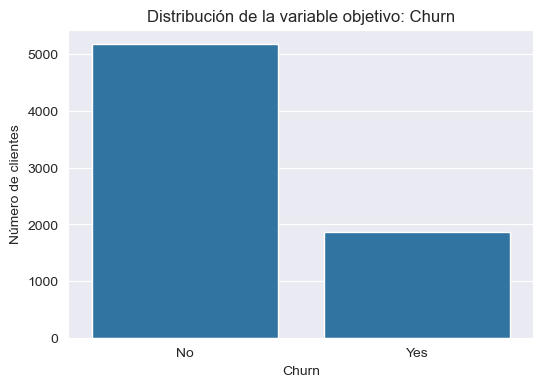

In [13]:
# Gráfico de la variable objetivo
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=data)
plt.title("Distribución de la variable objetivo: Churn")
plt.xlabel("Churn")
plt.ylabel("Número de clientes")
plt.show()

## 2. Revisión de variables numéricas

Variables numéricas: `Tenure`, `MonthlyCharges`, `TotalCharges`.
Objetivos:
- Revisar distribución y rangos.
- Detectar valores atípicos.
- Identificar patrones preliminares respecto a Churn.


In [15]:
# Convertir TotalCharges a numérico (puede contener espacios)
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

# Resumen estadístico
data[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


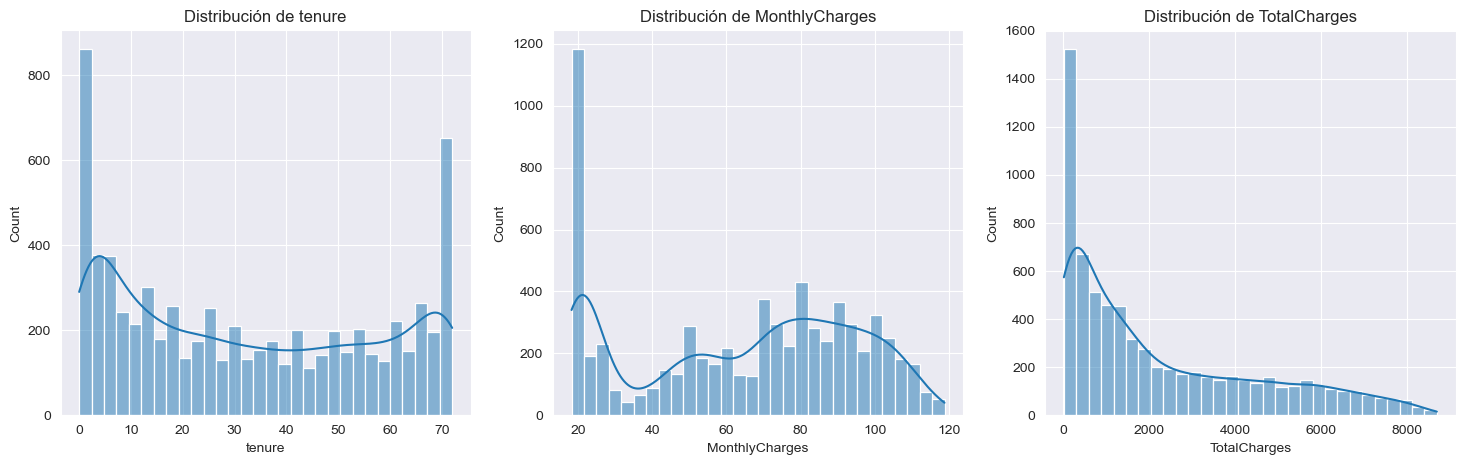

In [17]:
# Distribución de variables numéricas
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(18,5))
for i, col in enumerate(num_cols):
    plt.subplot(1, 3, i+1)
    sns.histplot(data[col], kde=True, bins=30)
    plt.title(f'Distribución de {col}')
plt.show()

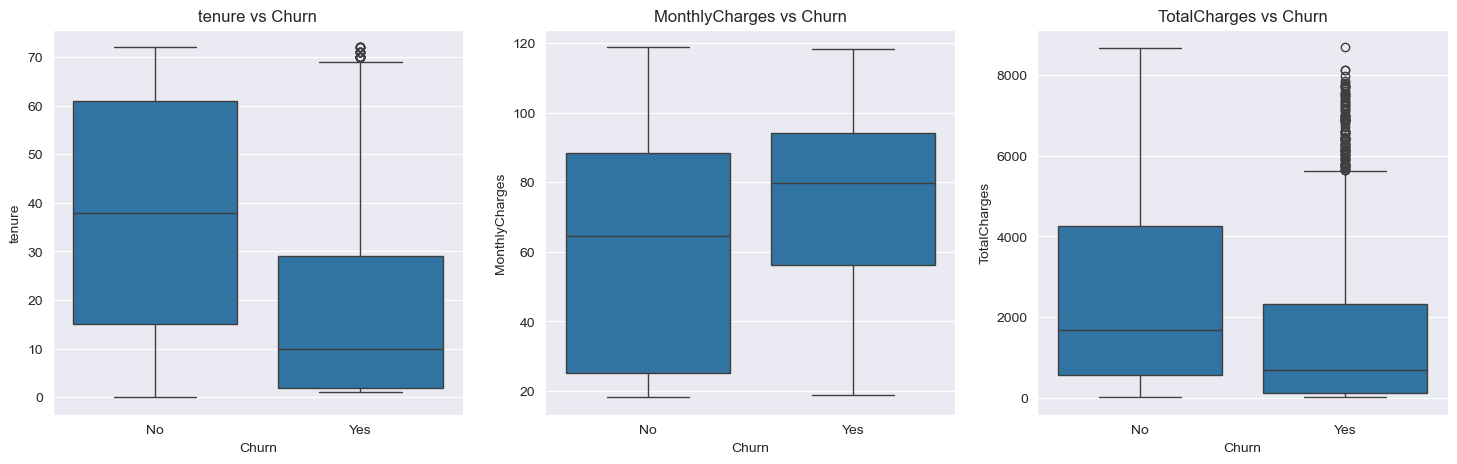

In [18]:
# Boxplots de variables numéricas según churn
plt.figure(figsize=(18,5))
for i, col in enumerate(num_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x='Churn', y=col, data=data)
    plt.title(f'{col} vs Churn')
plt.show()

## 3. Revisión de variables categóricas

Variables categóricas incluyen:
- Demografía: `Gender`, `SeniorCitizen`, `Partner`, `Dependents`
- Servicios: `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`
- Facturación y contrato: `Contract`, `PaperlessBilling`, `PaymentMethod`

Objetivos:
- Analizar proporciones de cada categoría.
- Detectar desequilibrio de clases.
- Observar relación preliminar con `Churn`.

In [22]:
# Selección de variables categóricas
cat_cols = [
    'ender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

# Función para mostrar proporciones
for col in cat_cols:
    print(f"\nColumna: {col}")
    display(data[col].value_counts(normalize=True))


Columna: gender


gender
Male      0.504756
Female    0.495244
Name: proportion, dtype: float64


Columna: SeniorCitizen


SeniorCitizen
0    0.837853
1    0.162147
Name: proportion, dtype: float64


Columna: Partner


...

Contract
Month-to-month    0.550192
Two year          0.240664
One year          0.209144
Name: proportion, dtype: float64


Columna: PaperlessBilling


PaperlessBilling
Yes    0.592219
No     0.407781
Name: proportion, dtype: float64


Columna: PaymentMethod


PaymentMethod
Electronic check             0.335794
Mailed check                 0.228880
Bank transfer (automatic)    0.219225
Credit card (automatic)      0.216101
Name: proportion, dtype: float64

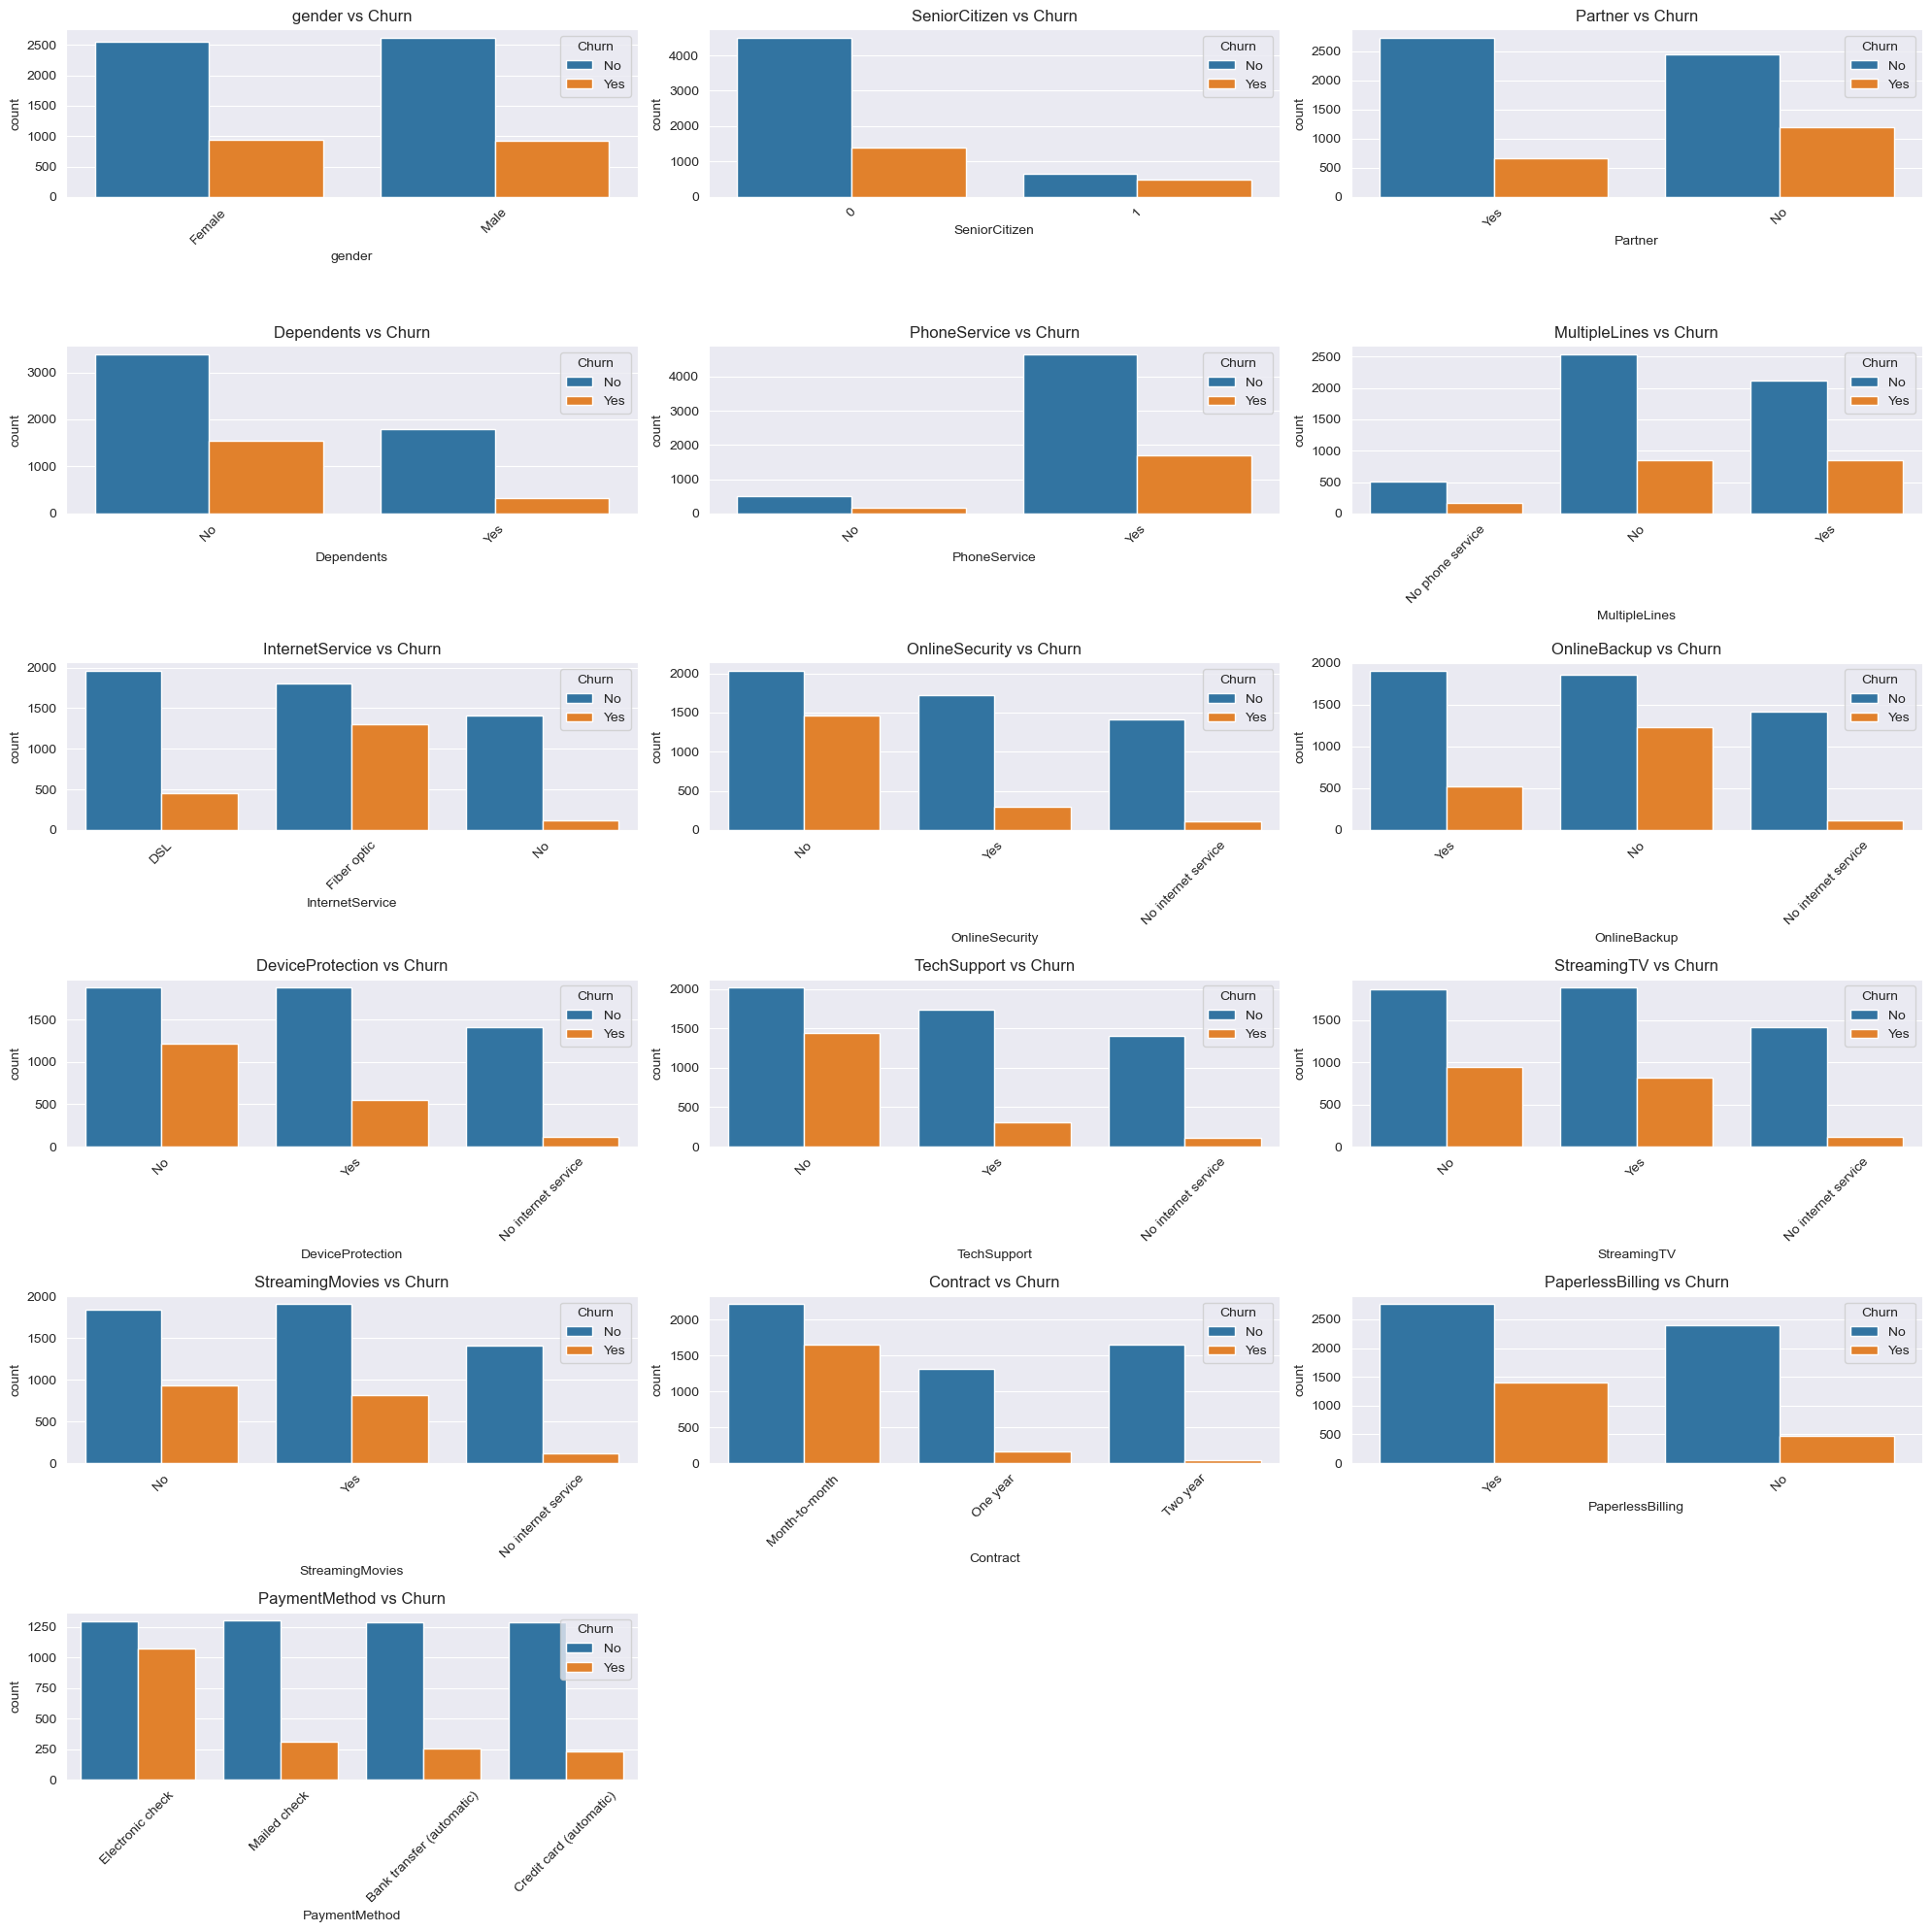

In [23]:
# Gráficos de variables categóricas frente a Churn
plt.figure(figsize=(20,20))
for i, col in enumerate(cat_cols):
    plt.subplot(6,3,i+1)
    sns.countplot(x=col, hue='Churn', data=data)
    plt.xticks(rotation=45)
    plt.title(f'{col} vs Churn')
plt.tight_layout()
plt.show()

## 4. Correlación y relaciones entre variables

- Analizamos la correlación entre variables numéricas y la variable objetivo.
- Identificamos posibles variables predictoras fuertes.

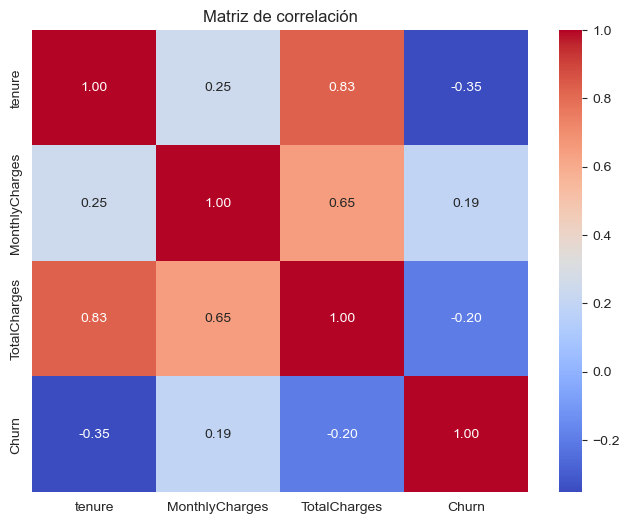

In [24]:
# Correlación numérica
corr = data[num_cols + ['Churn']].copy()
corr['Churn'] = data['Churn'].map({'No':0, 'Yes':1})
plt.figure(figsize=(8,6))
sns.heatmap(corr.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

## 5. Insights preliminares

1. Clientes con menor `Tenure` y mayor `MonthlyCharges` parecen tener más probabilidad de churn.
2. Contratos a corto plazo (`Month-to-month`) muestran mayor churn.
3. Algunos servicios como `OnlineSecurity` o `TechSupport` parecen correlacionar con menor churn.
4. Hay valores faltantes en `TotalCharges`, probablemente por clientes recientes con 0 meses de tenure.

Estos insights guiarán el **preprocesamiento y feature engineering**, que será el siguiente paso en nuestro proyecto.